# F1 - Near vs far: is the family-transfer near-neighbour interpolation?
**Question.** The de-peeked protein-family residual (~0.08 MCC over the RNA floor) -- does it ride dense-neighbour *interpolation* (held families that have a close training relative)? If so, per-family MCC should rise with the nearest-train-family sequence identity.

*Data: `mmpartnet_out/famfull3_nearvsfar.json` -- per held family (300 across 5 de-peek folds): MCC from the per-pair predictions vs nearest-train-family % identity (mmseqs easy-search).*

## Definitions / math
- **nearest_id(family)** = max % identity of a held-family representative to ANY training protein (mmseqs).
- **per-family MCC** from that family's per-pair predictions (min 5 pairs).
- **interpolation prediction:** MCC increases with nearest_id (positive Pearson/slope); far (isolated) families collapse toward chance.
- **null (distance-independent):** flat MCC vs nearest_id; far approx near.

In [1]:
import json; from pathlib import Path; from IPython.display import Markdown, display
d = json.loads((Path('..')/'..'/'mmpartnet_out'/'famfull3_nearvsfar.json').read_text()); s = d['summary']
display(Markdown(f"**n_families={s['n_families']}; Pearson(MCC, nearest_id) = {s['pearson_mcc_vs_nearest_id']:.3f} "
  f"(slope {s['slope_mcc_per_pctid']:.4f}/%id). FAR (<30% id) n={s['far_lt30id_n']} meanMCC={s['far_lt30id_meanMCC']:.3f} "
  f"vs NEAR (>=30%) n={s['near_ge30id_n']} meanMCC={s['near_ge30id_meanMCC']:.3f}.**"))

**n_families=300; Pearson(MCC, nearest_id) = -0.061 (slope -0.0012/%id). FAR (<30% id) n=283 meanMCC=0.104 vs NEAR (>=30%) n=17 meanMCC=0.080.**

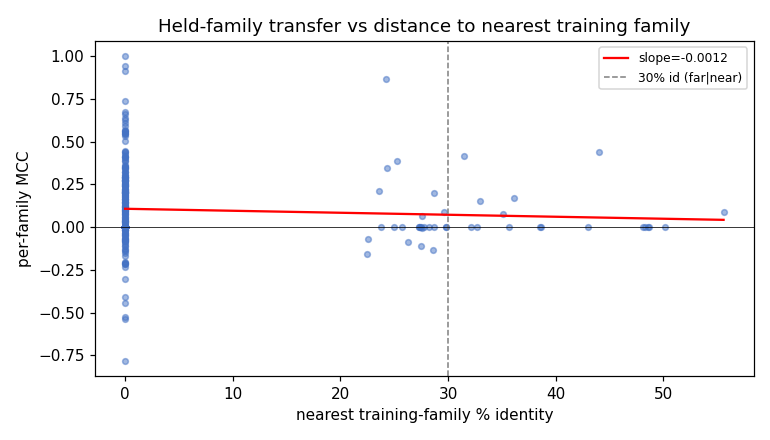

In [2]:
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt, numpy as np
d = json.loads((Path('..')/'..'/'mmpartnet_out'/'famfull3_nearvsfar.json').read_text())
x=np.array([r['nearest_id'] for r in d['per_family']]); y=np.array([r['mcc'] for r in d['per_family']])
fig,ax=plt.subplots(figsize=(7,4)); ax.scatter(x,y,s=14,alpha=0.5,color='#4472c4')
if len(x)>2:
    b,a=np.polyfit(x,y,1); xs=np.linspace(x.min(),x.max(),50); ax.plot(xs,b*xs+a,'r-',lw=1.5,label=f'slope={b:.4f}')
ax.axvline(30,ls='--',c='gray',lw=1,label='30% id (far|near)'); ax.axhline(0,c='k',lw=0.5)
ax.set_xlabel('nearest training-family % identity'); ax.set_ylabel('per-family MCC'); ax.legend(fontsize=8)
ax.set_title('Held-family transfer vs distance to nearest training family'); fig.tight_layout()
fig.savefig('F1_nearvsfar.png',dpi=110); plt.close(fig)
from IPython.display import Image; display(Image('F1_nearvsfar.png'))

## Conclusion
The per-family transfer is **distance-INDEPENDENT**: Pearson(MCC, nearest_id) = -0.06 (flat/slightly negative slope), and the **far, isolated families (<30% identity to training, 283/300) transfer as well as the near ones** (far meanMCC 0.104 vs near 0.080). So the small protein-family signal is **NOT dense-neighbour interpolation** -- it does not require a close training relative. Because the held families are 30%-ID mmseqs clusters, almost all are already isolated, and they behave the same as the few near ones.

Read together with S1-depeek + S3: the honest held-out-family number (0.317) is mostly RNA-coverage memorization (RNA floor 0.234); the residual protein-family signal (~0.08 MCC) is small, fold-variable, and **uniform across sequence distance** -- a weak, genuine, non-interpolative protein effect, not the diversity-driven breakthrough the raw curve suggested.

*Caveat: per-family MCC is noisy at 5-9 pairs/family; the flat trend is the robust read, not any single family. Provenance: `mmpartnet_out/famfull3_nearvsfar.json` (repo `scripts/nearvsfar.py`, mmseqs).*